# Network Event Threat Triage

Heuristic detection and a supervised baseline on flow-like logs (`src_ip`, `dst_ip`, `port`, `bytes`).

**What this notebook does**
1. Scores each event with simple source/destination behavior flags (ports, fan-out, bytes, shared targets).
2. Aggregates per source IP and labels likely **port scan**, **network scan**, **brute force**, **beaconing**, or **data exfiltration**.
3. Trains an XGBoost classifier on those labels as a first ML pass.

**How to read the model results.** Labels are rule-based. The model is trained on features that those rules already use, so a high test score mainly shows the pipeline can recover the heuristics — not that it would detect unseen attacks in production.

Data: `network_events.csv` in this folder.

In [1]:
import pandas as pd
df = pd.read_csv("network_events.csv")

In [2]:
port_counts = df.groupby("src_ip")["port"].nunique()
threshold = 2
suspicious_src = port_counts[port_counts > threshold].index
df["suspicious_try"] = df["src_ip"].isin(suspicious_src)


srcip = df.groupby("src_ip")["dst_ip"].nunique()
too_much = 2
suspicious_ip = srcip[srcip >= too_much].index
df["suspicious_ip"] = df["src_ip"].isin(suspicious_ip)


bytes_num = df.groupby("src_ip")["bytes"].sum()
too_muchh = 9000
suspicious_bytes = bytes_num[bytes_num > too_muchh].index
df["suspicious_bytes"] = df["src_ip"].isin(suspicious_bytes)


spread = df.groupby(["src_ip", "port"])["dst_ip"].nunique()
too_muchhh = 3
suspicious_pair = spread[spread >= too_muchhh].index
df["suspicious_spread"] = pd.Series(list(zip(df["src_ip"], df["port"]))).isin(suspicious_pair)


many_src = df.groupby("dst_ip")["src_ip"].nunique()
too_muchhhh = 3
suspicious_target = many_src[many_src >= too_muchhhh].index
df["suspicious_target"] = df["dst_ip"].isin(suspicious_target)


df["suspicious_score"] = (df["suspicious_try"].astype(int) + df["suspicious_ip"].astype(int) + df["suspicious_bytes"].astype(int) + df["suspicious_spread"].astype(int) + df["suspicious_target"].astype(int))

df["risk_level"] = "low"
df.loc[df["suspicious_score"] == 0, "risk_level"] = "normal"
df.loc[df["suspicious_score"] == 1, "risk_level"] = "low"
df.loc[df["suspicious_score"] == 2, "risk_level"] = "medium"
df.loc[df["suspicious_score"] == 3, "risk_level"] = "high"
df.loc[df["suspicious_score"] == 4, "risk_level"] = "critical"


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df[["src_ip", "dst_ip", "bytes", "port", "suspicious_try", "suspicious_ip", "suspicious_bytes", "suspicious_spread", "suspicious_target", "suspicious_score", "risk_level",]]


,src_ip,dst_ip,bytes,port,suspicious_try,suspicious_ip,suspicious_bytes,suspicious_spread,suspicious_target,suspicious_score,risk_level
0,10.0.0.145,198.51.100.50,938,3389,False,False,True,False,True,2,medium
1,10.0.0.106,203.0.113.10,1074,3389,True,True,True,False,False,3,high
2,10.0.0.218,198.51.100.50,1148,22,False,True,True,False,True,3,high
3,10.0.0.138,1.1.1.1,4042,443,False,True,False,False,True,2,medium
4,10.0.0.110,192.0.2.10,643,25,True,True,True,False,True,4,critical
5,10.0.0.186,192.0.2.100,835,3389,True,True,True,False,True,4,critical
6,10.0.0.86,192.168.240.226,175,443,True,True,False,True,False,3,high
7,10.0.0.173,203.0.113.30,4625,587,True,True,True,False,True,4,critical
8,10.0.0.186,192.0.2.10,3565,53,True,True,True,False,True,4,critical
9,10.0.0.58,9.9.9.9,825,80,True,True,True,False,True,4,critical


In [4]:
df["src_event_count"] = df.groupby("src_ip")["src_ip"].transform("count")
df["bytes_sum"] = df.groupby("src_ip")["bytes"].transform("sum")
df["avg_bytes_per_event"] = (df["bytes_sum"] // df["src_event_count"])
df["max_bytes_per_event"] = df.groupby("src_ip")["bytes"].transform("max")
df["unique_ports_per_src_ip"] = df.groupby("src_ip")["port"].transform("nunique")
df["unique_dst_count"] = df.groupby("src_ip")["dst_ip"].transform("nunique")

df[["src_ip", "bytes", "src_event_count", "bytes_sum", "avg_bytes_per_event", "max_bytes_per_event", "unique_ports_per_src_ip", "unique_dst_count"]].drop_duplicates(subset="src_ip")


,src_ip,bytes,src_event_count,bytes_sum,avg_bytes_per_event,max_bytes_per_event,unique_ports_per_src_ip,unique_dst_count
0,10.0.0.145,938,10,9241,924,1170,1,1
1,10.0.0.106,1074,14,15582,1113,4016,5,3
2,10.0.0.218,1148,11,13176,1197,4621,2,2
3,10.0.0.138,4042,2,7277,3638,4042,2,2
4,10.0.0.110,643,5,11728,2345,3989,3,4
5,10.0.0.186,835,14,20369,1454,3899,5,4
6,10.0.0.86,175,11,4398,399,2339,3,11
7,10.0.0.173,4625,5,13836,2767,4625,3,3
9,10.0.0.58,825,7,15226,2175,4471,6,4
10,10.0.0.238,876,10,5287,528,1650,8,3


In [5]:
df["attack_type"] = "normal"


df.loc[
(df["attack_type"] == "normal") &
(df["max_bytes_per_event"] >= 8000) &
(df["bytes_sum"] >= 15000) &
(df["unique_dst_count"] <= 2),
"attack_type"
] = "data_exfiltration"


df.loc[
(df["attack_type"] == "normal") &
(df["unique_dst_count"] >= 4) &
(df["unique_ports_per_src_ip"] <= 2) &
(df["avg_bytes_per_event"] <= 500) &
(df["src_event_count"] >= 4),
"attack_type"
] = "network_scan"


df.loc[
(df["attack_type"] == "normal") &
(df["unique_ports_per_src_ip"] >= 6)&
(df["src_event_count"] >= 6)&
(df["avg_bytes_per_event"] <= 500)&
(df["unique_dst_count"] <= 2),
"attack_type"
] = "port_scan"


df.loc[
(df["attack_type"] == "normal") &
(df["src_event_count"] >= 6) &
(df["unique_dst_count"] == 1) &
(df["unique_ports_per_src_ip"] == 1)&
(df["avg_bytes_per_event"] >= 500),
"attack_type"
] = "brute_force"


df.loc[
(df["attack_type"] == "normal") &
(df["src_event_count"] >= 6) &
(df["unique_dst_count"] == 1) &
(df["unique_ports_per_src_ip"] == 1) &
(df["avg_bytes_per_event"] <= 300),
"attack_type"
] = "beaconing"

df = df[df["attack_type"].isin(["beaconing","brute_force","port_scan","network_scan","data_exfiltration","normal"])]

df[["src_ip","dst_ip","port","bytes","attack_type"]]


,src_ip,dst_ip,port,bytes,attack_type
0,10.0.0.145,198.51.100.50,3389,938,brute_force
1,10.0.0.106,203.0.113.10,3389,1074,normal
2,10.0.0.218,198.51.100.50,22,1148,normal
3,10.0.0.138,1.1.1.1,443,4042,normal
4,10.0.0.110,192.0.2.10,25,643,normal
5,10.0.0.186,192.0.2.100,3389,835,normal
6,10.0.0.86,192.168.240.226,443,175,normal
7,10.0.0.173,203.0.113.30,587,4625,normal
8,10.0.0.186,192.0.2.10,53,3565,normal
9,10.0.0.58,9.9.9.9,80,825,normal


In [6]:
reason_map = {
"port_scan": [
"Many unique ports contacted by the same source IP",
"Low average bytes per connection"
],
"network_scan": [
"Many unique destination IPs contacted",
"Low bytes per event",
"Multiple events from the same source"
],
"brute_force": [
"Repeated attempts to a single destination",
"Moderate traffic size per event"
],
"beaconing": [
"Frequent small periodic connections",
"Same destination and port"
],
"data_exfiltration": [
"Extremely large data transfer",
"High total bytes sent",
"Limited destination spread"
]
}

df["reasons"] = ""
df["reasons"] = df["attack_type"].map(reason_map)

df[df["attack_type"] != "normal"][["src_ip","src_event_count","bytes_sum","avg_bytes_per_event","max_bytes_per_event","unique_ports_per_src_ip","unique_dst_count","attack_type","reasons"]].drop_duplicates(subset="src_ip")


,src_ip,src_event_count,bytes_sum,avg_bytes_per_event,max_bytes_per_event,unique_ports_per_src_ip,unique_dst_count,attack_type,reasons
0,10.0.0.145,10,9241,924,1170,1,1,brute_force,"[Repeated attempts to a single destination, Mo..."
12,10.0.0.243,10,1831,183,267,1,1,beaconing,"[Frequent small periodic connections, Same des..."
25,10.0.0.107,10,1695,169,258,1,1,beaconing,"[Frequent small periodic connections, Same des..."
29,10.0.0.146,10,184753,18475,29421,1,1,data_exfiltration,"[Extremely large data transfer, High total byt..."
71,10.0.0.248,6,1459,243,444,6,1,port_scan,[Many unique ports contacted by the same sourc...
88,10.0.0.61,10,224697,22469,28778,1,1,data_exfiltration,"[Extremely large data transfer, High total byt..."
122,10.0.0.231,11,188628,17148,26572,1,2,data_exfiltration,"[Extremely large data transfer, High total byt..."
230,10.0.0.124,10,2021,202,273,1,1,beaconing,"[Frequent small periodic connections, Same des..."


In [7]:
df["attack_type"].value_counts()

attack_type
normal               906
data_exfiltration     31
beaconing             30
brute_force           10
port_scan              6
Name: count, dtype: int64

In [8]:
attack_summary = (df[df["attack_type"] != "normal"].groupby(["src_ip", "attack_type"]).agg(attack_events=("attack_type", "size"),total_bytes=("bytes", "sum")).sort_values("attack_events", ascending=False))

attack_summary

,,attack_events,total_bytes
src_ip,attack_type,,
10.0.0.231,data_exfiltration,11,188628
10.0.0.107,beaconing,10,1695
10.0.0.145,brute_force,10,9241
10.0.0.124,beaconing,10,2021
10.0.0.146,data_exfiltration,10,184753
10.0.0.243,beaconing,10,1831
10.0.0.61,data_exfiltration,10,224697
10.0.0.248,port_scan,6,1459


## Supervised baseline

Features are the per-source aggregates from above. Labels are the heuristic `attack_type` values, so this step checks whether a tree model can replay those rules — not whether it generalizes to new malware or new networks.

In [9]:
X = df[["src_event_count", "bytes_sum", "avg_bytes_per_event", "max_bytes_per_event", "unique_ports_per_src_ip", "unique_dst_count"]]
y = df["attack_type"]



In [10]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(786, 6)
(197, 6)
(786,)
(197,)
attack_type
normal               724
data_exfiltration     25
beaconing             24
brute_force            8
port_scan              5
Name: count, dtype: int64
attack_type
normal               182
data_exfiltration      6
beaconing              6
brute_force            2
port_scan              1
Name: count, dtype: int64


In [14]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from xgboost import XGBClassifier

In [16]:
model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1)

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
label_encoder = LabelEncoder()

In [19]:
y_train_encoded = label_encoder.fit_transform(y_train)

In [20]:
label_encoder.classes_

array(['beaconing', 'brute_force', 'data_exfiltration', 'normal',
       'port_scan'], dtype=object)

In [22]:
y_test_encoded = label_encoder.transform(y_test)
y_test_encoded


array([3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2,
       3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3,
       3, 3, 3, 0, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3])

In [23]:
model.fit(X_train, y_train_encoded)

c:\Users\lawan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:06:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "n_estimnators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) 

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred_labels = label_encoder.inverse_transform(y_pred)

In [26]:
y_pred_labels

array(['normal', 'normal', 'data_exfiltration', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'beaconing',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'data_exfiltration',
       'data_exfiltration', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'beaconing', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'beaconing', 'normal', 'normal', 'normal', 'no

In [27]:
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_labels
})

comparison

,actual,predicted
0,normal,normal
1,normal,normal
2,data_exfiltration,data_exfiltration
3,normal,normal
4,normal,normal
5,normal,normal
6,normal,normal
7,normal,normal
8,normal,normal
9,normal,normal


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print(accuracy)

1.0


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

                   precision    recall  f1-score   support

        beaconing       1.00      1.00      1.00         6
      brute_force       1.00      1.00      1.00         2
data_exfiltration       1.00      1.00      1.00         6
           normal       1.00      1.00      1.00       182
        port_scan       1.00      1.00      1.00         1

         accuracy                           1.00       197
        macro avg       1.00      1.00      1.00       197
     weighted avg       1.00      1.00      1.00       197



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

cm

array([[  6,   0,   0,   0,   0],
       [  0,   2,   0,   0,   0],
       [  0,   0,   6,   0,   0],
       [  0,   0,   0, 182,   0],
       [  0,   0,   0,   0,   1]])

In [31]:
model.feature_importances_

array([0.17197901, 0.09977011, 0.25053903, 0.11286773, 0.14799486,
       0.21684934], dtype=float32)

In [32]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


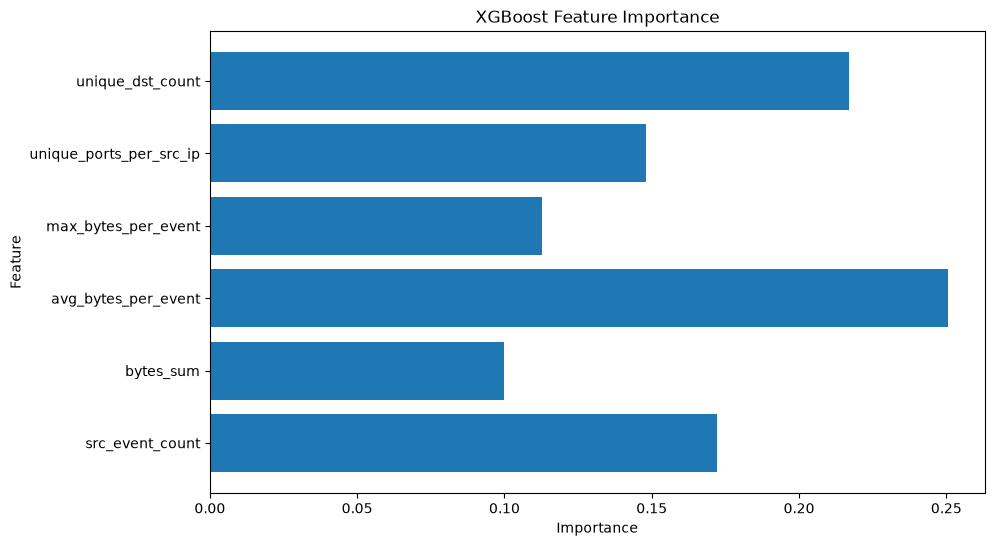

In [33]:
import matplotlib.pyplot as plt

features = X.columns
importance = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()